### Carregamento dos Dados

In [129]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# importando a base de dados e modificando os tipos de dados para o ideal em cada coluna.

df  = pd.read_csv('Base Varejo.csv', sep=';', dtype= {'CO_ID':str,'CL_ID':str,'CL_GENERO':'category','CL_SEG':'category','PR_ID':str,'PR_CAT':'category'})

# criaçao da copia da nossa base de dados

df_copy = df.copy()

# alterando o formato da coluna 'DATA'

df_copy['DATA'] = pd.to_datetime(df['DATA'], dayfirst=True)

In [104]:
# recolhendo amostras
df_copy.head(10)

,DATA,CO_ID,CL_ID,CL_GENERO,CL_EC,CL_FHL,CL_SEG,PR_ID,PR_CAT,PR_NOME,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13
0,2019-02-01,1000,534,M,4,1,C,67,BEBIDAS,REFRIGERANTE GUARANA,NaN,NaN,NaN,NaN
1,2019-02-01,1000,534,M,4,1,C,70,BEBIDAS,REFRIGERANTE OUTROS,NaN,NaN,NaN,NaN
2,2019-02-01,1000,534,M,4,1,C,178,HIGIENE,LENCO UMEDECIDO,NaN,NaN,NaN,NaN
3,2019-02-01,1000,534,M,4,1,C,4,ALIMENTOS,ABACAXI,NaN,NaN,NaN,NaN
4,2019-02-01,1000,534,M,4,1,C,175,LIMPEZA,LIMPADOR MULTIUSO,NaN,NaN,NaN,NaN
5,2019-02-01,1000,534,M,4,1,C,187,HIGIENE,HASTES FLEXIVEIS,NaN,NaN,NaN,NaN
6,2019-02-01,1000,534,M,4,1,C,163,ALIMENTOS,MORTADELA,NaN,NaN,NaN,NaN
7,2019-02-01,1000,534,M,4,1,C,11,ALIMENTOS,AZEITE,NaN,NaN,NaN,NaN
8,2019-02-01,1000,534,M,4,1,C,95,LIMPEZA,AMACIANTE,NaN,NaN,NaN,NaN
9,2019-02-01,1000,534,M,4,1,C,198,BEBIDAS,ENERGETICO,NaN,NaN,NaN,NaN


In [105]:
# verificaçao de tipos de dados

df_copy.info()

<class 'pandas.DataFrame'>
RangeIndex: 830000 entries, 0 to 829999
Data columns (total 14 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   DATA         830000 non-null  datetime64[us]
 1   CO_ID        830000 non-null  str           
 2   CL_ID        830000 non-null  str           
 3   CL_GENERO    830000 non-null  category      
 4   CL_EC        830000 non-null  int64         
 5   CL_FHL       830000 non-null  int64         
 6   CL_SEG       830000 non-null  category      
 7   PR_ID        830000 non-null  str           
 8   PR_CAT       830000 non-null  category      
 9   PR_NOME      830000 non-null  str           
 10  Unnamed: 10  0 non-null       float64       
 11  Unnamed: 11  0 non-null       float64       
 12  Unnamed: 12  0 non-null       float64       
 13  Unnamed: 13  0 non-null       float64       
dtypes: category(3), datetime64[us](1), float64(4), int64(2), str(4)
memory usage: 72.0 MB


### Identificando Problemas

In [106]:
# verificaçao com precentual de nulos:

print((df_copy.isnull().sum() / len(df_copy) * 100).round(2))

DATA             0.0
CO_ID            0.0
CL_ID            0.0
CL_GENERO        0.0
CL_EC            0.0
CL_FHL           0.0
CL_SEG           0.0
PR_ID            0.0
PR_CAT           0.0
PR_NOME          0.0
Unnamed: 10    100.0
Unnamed: 11    100.0
Unnamed: 12    100.0
Unnamed: 13    100.0
dtype: float64


In [107]:
# verificando duplicatas

df_copy.duplicated().sum()

# iremos logo resolver este problema em questao

np.int64(96553)

### Tratamento e Limpeza dos Dados

In [108]:
# exibiçao em dataframe, para analisarmos melhor a questao das duplicatas

# filtra a base, mostrando as linhas que possuem copias iguais
duplicatas = df_copy[df_copy.duplicated(keep=False)]

# como queremos descobrir se a questao das duplicatas tem algo haver com o id do cliente e o id do produto as ordemos dessa forma para  que facilite nossa analise
duplicatas.sort_values(by=['CO_ID', 'PR_ID']).head(10)


,DATA,CO_ID,CL_ID,CL_GENERO,CL_EC,CL_FHL,CL_SEG,PR_ID,PR_CAT,PR_NOME,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13
7,2019-02-01,1000,534,M,4,1,C,11,ALIMENTOS,AZEITE,NaN,NaN,NaN,NaN
46,2019-02-01,1000,534,M,4,1,C,11,ALIMENTOS,AZEITE,NaN,NaN,NaN,NaN
14,2019-02-01,1000,534,M,4,1,C,13,ALIMENTOS,BANANA,NaN,NaN,NaN,NaN
19,2019-02-01,1000,534,M,4,1,C,13,ALIMENTOS,BANANA,NaN,NaN,NaN,NaN
15,2019-02-01,1000,534,M,4,1,C,218,ALIMENTOS,BIFE DE COXAO MOLE,NaN,NaN,NaN,NaN
50,2019-02-01,1000,534,M,4,1,C,218,ALIMENTOS,BIFE DE COXAO MOLE,NaN,NaN,NaN,NaN
34,2019-02-01,1000,534,M,4,1,C,225,ALIMENTOS,ATUM,NaN,NaN,NaN,NaN
51,2019-02-01,1000,534,M,4,1,C,225,ALIMENTOS,ATUM,NaN,NaN,NaN,NaN
3,2019-02-01,1000,534,M,4,1,C,4,ALIMENTOS,ABACAXI,NaN,NaN,NaN,NaN
40,2019-02-01,1000,534,M,4,1,C,4,ALIMENTOS,ABACAXI,NaN,NaN,NaN,NaN


Apos analisar os indices, descobrimos um padrao, como da para observar, os numeros dos indices estao espaçados, oque provavelmente significa que ao passar no caixa os produtos, eles foram sendo passados de maneira meio espaçada (de acordo com o indice), oque significa que nao foi um erro do sistema, entao a compra dos produtos esta correta, e a questao das linhas duplicadas, atesta que nao ha erro algum, caso apagassemos, iriamos perder uma grande quantidade de dados valiossimos para a empresa em questao


In [109]:
# apos a analise anterior, decidimos criar uma nova coluna de quantidade, contendo as linhas duplicadas

coluna = df_copy.columns.tolist()
df_copy = df_copy.groupby(coluna, dropna=False).size().reset_index(name='QTD_PR')

df_copy[df_copy['CO_ID'] == '1000'].head(10)

,DATA,CO_ID,CL_ID,CL_GENERO,CL_EC,CL_FHL,CL_SEG,PR_ID,PR_CAT,PR_NOME,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13,QTD_PR
6492,2019-02-01,1000,534,M,4,1,C,108,LIMPEZA,REMOVEDOR,NaN,NaN,NaN,NaN,1
6493,2019-02-01,1000,534,M,4,1,C,11,ALIMENTOS,AZEITE,NaN,NaN,NaN,NaN,2
6494,2019-02-01,1000,534,M,4,1,C,121,ALIMENTOS,UVA,NaN,NaN,NaN,NaN,1
6495,2019-02-01,1000,534,M,4,1,C,123,LIMPEZA,TIRA MANCHA,NaN,NaN,NaN,NaN,1
6496,2019-02-01,1000,534,M,4,1,C,13,ALIMENTOS,BANANA,NaN,NaN,NaN,NaN,2
6497,2019-02-01,1000,534,M,4,1,C,132,HIGIENE,SABONETE,NaN,NaN,NaN,NaN,1
6498,2019-02-01,1000,534,M,4,1,C,135,LIMPEZA,RODO,NaN,NaN,NaN,NaN,1
6499,2019-02-01,1000,534,M,4,1,C,136,ALIMENTOS,RICOTA,NaN,NaN,NaN,NaN,1
6500,2019-02-01,1000,534,M,4,1,C,143,BEBIDAS,REFRIGERANTE GUARANA,NaN,NaN,NaN,NaN,1
6501,2019-02-01,1000,534,M,4,1,C,149,ALIMENTOS,QUEIJO MUSSARELA,NaN,NaN,NaN,NaN,1


In [110]:
# removendo colunas inteiramente vazias, pois nao fara sentido ter elas dentro da nossa base de dados que posteriormente sera utilizada por alguem:
df_copy = df_copy.drop(columns= ['Unnamed: 10', 'Unnamed: 11', 'Unnamed: 12', 'Unnamed: 13'])

In [111]:
# correcao de inconssisetncias nas colunas PR_CAT e PR_NOME

df_copy['PR_CAT'] = df_copy['PR_CAT'].str.capitalize()
df_copy['PR_NOME'] = df_copy['PR_NOME'].str.capitalize()

In [112]:
# modificando o estado civil para estar condizente com a documentaçao e as regras de negocio da empresa:

map_df = {1:'Casado/Uniao Estavel', 2:'Divorciado', 3:'Separado', 4:'Solteiro', 5:'Viuvo'}
df_copy['CL_EC'] = df_copy['CL_EC'].map(map_df)

In [113]:
# vendo quantas linhas temos valores nulos/ausentes ou #N/D
df_copy[df_copy['PR_CAT'] == '#n/d'].shape[0]

3228

In [114]:
# vamos substituir a string '#N/D' por valores nulos, pois na etapa de verificaçao nao foi constatado
df_copy['PR_CAT'] = df_copy['PR_CAT'].replace('#n/d', np.nan)
df_copy['PR_NOME'] = df_copy['PR_NOME'].replace('#n/d', np.nan)

# removendo nulos
df_copy = df_copy.dropna(subset=['PR_CAT', 'PR_NOME'])

# transformando novamente o PR_CAT em categoria
df_copy['PR_CAT'] = df_copy['PR_CAT'].astype('category')



Removemos os valores nulos apos analisar as colunas PR_CAT, PR_NOME e PR_ID pois com os dados atuais se torna impossivel de recuperar esses 3.228 valores nulos/ausentes, iremos remover eles pois como sao poucos e nao tem maneira alguma de os recuperar, nao farao falta na nossa base


#### deixar aqui por enqanto

In [115]:
# Filtra apenas colunas de texto (object), categorias (category) e texto (strings)
df_copy.describe(include=['object', 'category', 'str'])

,CO_ID,CL_ID,CL_GENERO,CL_EC,CL_SEG,PR_ID,PR_CAT,PR_NOME
count,730219,730219,730219,730219,730219,730219,730219,730219
unique,18469,1000,2,5,3,228,6,117
top,173489,822,F,Separado,B,51,Alimentos,Presunto cozido
freq,81,1527,380735,188238,466441,3322,384197,12719


### Estatísticas Descritivas

In [116]:
# filtraremos apenas colunas de texto (object), categorias (category) e texto (strings)
df_copy.describe(include=['object', 'category', 'str'])

,CO_ID,CL_ID,CL_GENERO,CL_EC,CL_SEG,PR_ID,PR_CAT,PR_NOME
count,730219,730219,730219,730219,730219,730219,730219,730219
unique,18469,1000,2,5,3,228,6,117
top,173489,822,F,Separado,B,51,Alimentos,Presunto cozido
freq,81,1527,380735,188238,466441,3322,384197,12719


In [117]:
# obtendo as principais estatisticas descritivas dos dados

def descritivas(data):
  variaveis = data.select_dtypes(include=np.number)
  desc = variaveis.describe().T
  desc["CV"] = desc["std"]/desc["mean"]
  desc["Skew"] = variaveis.skew()
  desc["Kurtosis"] = variaveis.kurt()
  ordered_cols = [
      "count", "mean", "std", "CV",
      "min", "25%", "50%", "75%", "max",
      "Skew", "Kurtosis"
  ]
  desc = desc[ordered_cols]
  return desc.round(2)


In [118]:
descritivas(df_copy[['CL_FHL']])

,count,mean,std,CV,min,25%,50%,75%,max,Skew,Kurtosis
CL_FHL,730219.0,1.15,1.42,1.24,0.0,0.0,0.0,2.0,4.0,0.82,-0.79


### Analise Exploratorio e Agrupamentos

In [142]:
# quem compra mais em volume de produtos?
volume_cliente = df_copy.groupby('CL_ID')['QTD_PR'].sum().reset_index()
volume_cliente = volume_cliente.rename(columns={'QTD_PR': 'Qtd_Produtos'})

top_clientes_volume = volume_cliente.sort_values(by='Qtd_Produtos', ascending=False).head(10)

display(top_clientes_volume)

,CL_ID,Qtd_Produtos
804,822,1772
429,485,1644
300,369,1524
331,397,1501
969,971,1493
27,122,1459
14,110,1426
360,422,1421
808,826,1410
223,3,1398


In [ ]:
# verificaçao de clientes padrao ouro

display(volume_cliente['Qtd_Produtos'].describe())
percentis = volume_cliente['Qtd_Produtos'].quantile([0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99])
display(percentis)

count    1000.000000
mean      826.350000
std       227.409165
min       298.000000
25%       657.000000
50%       818.500000
75%       977.250000
max      1772.000000
Name: Qtd_Produtos, dtype: float64

0.10     550.90
0.25     657.00
0.50     818.50
0.75     977.25
0.90    1112.00
0.95    1238.05
0.99    1396.02
Name: Qtd_Produtos, dtype: float64

#### Quais categorias vendem mais (em volume total)?

In [138]:
# Quais categorias vendem mais (em volume total)?
vendas_categoria = df_copy.groupby('PR_CAT')['QTD_PR'].sum().reset_index()
vendas_categoria = vendas_categoria.rename(columns={'QTD_PR': 'Volume_Total_Vendido'})

# Ordenando para ver a mais vendida no topo
vendas_categoria = vendas_categoria.sort_values(by='Volume_Total_Vendido', ascending=False)

display(vendas_categoria)

,PR_CAT,Volume_Total_Vendido
1,Alimentos,434767
3,Higiene,155574
4,Limpeza,145754
2,Bebidas,43299
5,Pet,32399
0,Acessorios,14557


In [149]:
# Pega o nome da categoria que ficou em 1º lugar no seu código original
categoria_campea = vendas_categoria.iloc[0]['PR_CAT']
print(f"Analisando a Categoria Campeã: {categoria_campea}\n")

# Filtra o dataframe só para essa categoria e agrupa por Produto
df_campea = df_copy[df_copy['PR_CAT'] == categoria_campea]

produtos_da_categoria = df_campea.groupby('PR_NOME')['QTD_PR'].sum().reset_index() # Troque 'ID_PRODUTO' ou 'NOME_PRODUTO' se tiver
produtos_da_categoria = produtos_da_categoria.rename(columns={'QTD_PR': 'Volume'})
produtos_da_categoria = produtos_da_categoria.sort_values(by='Volume', ascending=False).head(10)

display(produtos_da_categoria)

Analisando a Categoria Campeã: Alimentos



,PR_NOME,Volume
50,Presunto cozido,14381
57,Sardinha,7490
10,Banana,7385
13,Bife de coxao mole,7355
48,Papinha infantil,7346
56,Salgadinhos de milho,7345
22,Coracao de frango,7342
54,Ricota,7334
17,Cebola,7321
11,Batata,7309


In [150]:
# Supondo que você tenha uma coluna 'DATA' já no formato datetime do pandas
# Criamos uma coluna apenas com o Mês
df_copy['Mes'] = df_copy['DATA'].dt.month

# Vendas da categoria por mês
sazonalidade = df_copy.groupby(['PR_CAT', 'Mes'])['QTD_PR'].sum().reset_index()

# Para visualizar melhor, podemos transformar isso em uma tabela dinâmica (Pivot Table)
pivot_sazonalidade = sazonalidade.pivot(index='PR_CAT', columns='Mes', values='QTD_PR').fillna(0)

display(pivot_sazonalidade)

Mes,1,2,3,4,5,6,7,8,9,10,11,12
PR_CAT,,,,,,,,,,,,
Acessorios,1480,1345,1092,1155,1467,1209,1146,1170,1181,1284,769,1259
Alimentos,43819,39771,33609,35065,43199,35539,36117,34232,36102,38836,21502,36976
Bebidas,4341,3923,3286,3511,4355,3517,3568,3471,3647,3891,2165,3624
Higiene,15829,14529,12072,12515,15237,12741,12905,12452,12754,13722,7638,13180
Limpeza,14877,13279,11518,11703,14466,11844,12233,11452,11958,12977,7069,12378
Pet,3241,3009,2532,2673,3187,2651,2718,2519,2645,2878,1606,2740


#### Como variam as vendas ao longo do tempo?

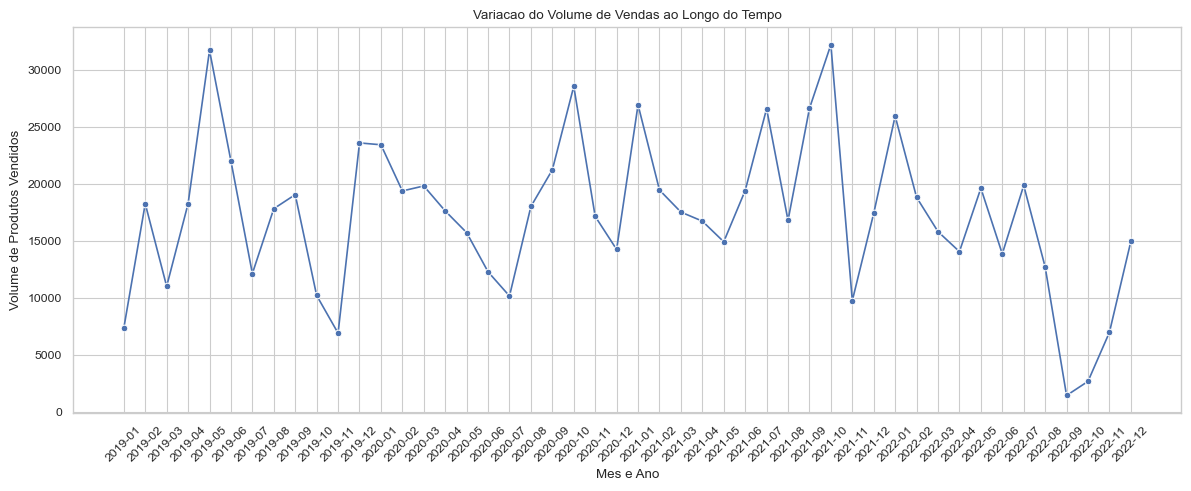

In [140]:
# Criando uma coluna de Ano-Mês para granularidade temporal adequada
df_copy['Ano_Mes'] = df_copy['DATA'].dt.to_period('M')

# Agrupando as vendas ao longo dos meses
vendas_tempo = df_copy.groupby('Ano_Mes')['QTD_PR'].sum().reset_index()

# Convertendo o Ano_Mes de volta para string para plotagem no Seaborn
vendas_tempo['Ano_Mes'] = vendas_tempo['Ano_Mes'].astype(str)

# Um gráfico de linha simples responde perfeitamente "como varia ao longo do tempo"
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 5))
sns.lineplot(data=vendas_tempo, x='Ano_Mes', y='QTD_PR', marker='o')
plt.title('Variacao do Volume de Vendas ao Longo do Tempo')
plt.xlabel('Mes e Ano')
plt.ylabel('Volume de Produtos Vendidos')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [141]:
# 1. Extrair o dia da semana (0 = Segunda, 6 = Domingo)
df_copy['Dia_Semana'] = df_copy['DATA'].dt.dayofweek

# Se preferir o nome do dia em português, pode mapear:
dias_map = {0: 'Segunda', 1: 'Terça', 2: 'Quarta', 3: 'Quinta', 4: 'Sexta', 5: 'Sábado', 6: 'Domingo'}
df_copy['Nome_Dia'] = df_copy['Dia_Semana'].map(dias_map)

# 2. Agrupar para ver o volume de vendas por dia da semana
vendas_por_dia = df_copy.groupby('Nome_Dia')['QTD_PR'].sum().reindex(list(dias_map.values())).reset_index()
display(vendas_por_dia)

,Nome_Dia,QTD_PR
0,Segunda,111288
1,Terça,101194
2,Quarta,152908
3,Quinta,105030
4,Sexta,132019
5,Sábado,93979
6,Domingo,129932


In [143]:
# 1. Primeiro, descobrimos o total de itens de cada compra (CO_ID) e o segmento do cliente
cesta_por_compra = df_copy.groupby(['CO_ID', 'CL_SEG'])['QTD_PR'].sum().reset_index()

# 2. Depois, calculamos a média de itens que cada segmento costuma levar por compra
media_cesta_segmento = cesta_por_compra.groupby('CL_SEG')['QTD_PR'].mean().reset_index()
media_cesta_segmento = media_cesta_segmento.rename(columns={'QTD_PR': 'Media_Itens_por_Compra'})

display(media_cesta_segmento)

,CL_SEG,Media_Itens_por_Compra
0,A,45.205764
1,B,44.576725
2,C,44.990265


In [144]:
# Agrupando por Gênero e Categoria para ver a distribuição do volume vendido
afinidade_genero = df_copy.groupby(['CL_GENERO', 'PR_CAT'])['QTD_PR'].sum().reset_index()

# Calculando a percentagem que cada categoria representa dentro de cada gênero
afinidade_genero['%_Dentro_do_Genero'] = (
    afinidade_genero['QTD_PR'] / 
    afinidade_genero.groupby('CL_GENERO')['QTD_PR'].transform('sum')
) * 100

display(afinidade_genero.sort_values(by=['CL_GENERO', '%_Dentro_do_Genero'], ascending=[True, False]))

,CL_GENERO,PR_CAT,QTD_PR,%_Dentro_do_Genero
1,F,Alimentos,226575,52.611353
3,F,Higiene,80991,18.806338
4,F,Limpeza,76298,17.716610
2,F,Bebidas,22345,5.188572
5,F,Pet,16749,3.889165
0,F,Acessorios,7700,1.787962
7,M,Alimentos,208192,52.614660
9,M,Higiene,74583,18.848751
10,M,Limpeza,69456,17.553046
8,M,Bebidas,20954,5.295533


In [145]:
# Calcular a quantidade de visitas únicas (compras diferentes) que cada cliente faz
visitas_por_cliente = df_copy.groupby(['CL_ID', 'CL_EC'])['CO_ID'].nunique().reset_index()

# Calcular a média de visitas por perfil de Estado Civil
recorrencia_perfil = visitas_por_cliente.groupby('CL_EC')['CO_ID'].mean().reset_index()
recorrencia_perfil = recorrencia_perfil.rename(columns={'CO_ID': 'Media_Vezes_que_comprou'})

display(recorrencia_perfil.sort_values(by='Media_Vezes_que_comprou', ascending=False))

,CL_EC,Media_Vezes_que_comprou
2,Separado,19.044000
0,Casado/Uniao Estavel,18.412017
1,Divorciado,18.390756
3,Solteiro,18.127490
4,Viuvo,17.535714


### Graficos

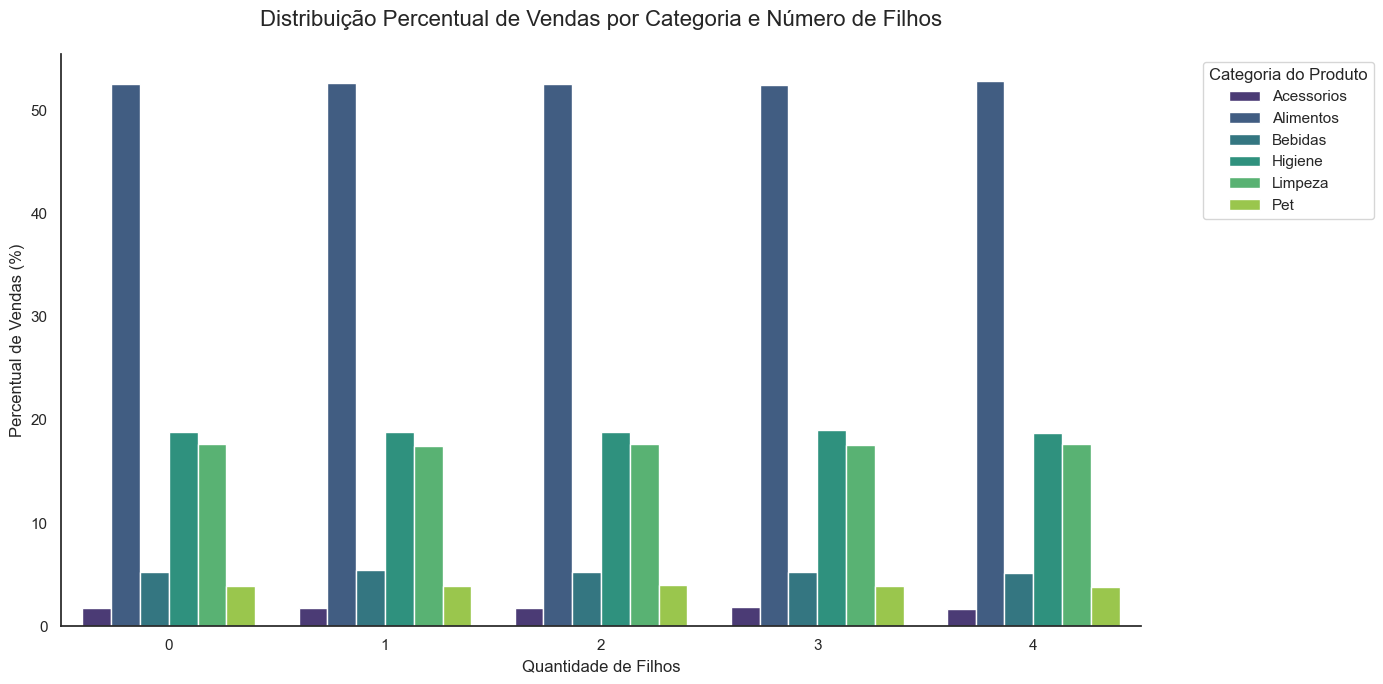

In [ ]:
sns.set_theme(style="white", context="talk")
plt.figure(figsize=(14, 7))


grafico_barras = sns.barplot(
    data=compras_filho, 
    x='CL_FHL', 
    y='% Vendas', 
    hue='PR_CAT', 
    palette='viridis'
)
sns.despine()

plt.title('Distribuicao Percentual de Vendas por Categoria e Numero de Filhos', fontsize=16, pad=20)
plt.xlabel('Quantidade de Filhos', fontsize=12)
plt.ylabel('Percentual de Vendas (%)', fontsize=12)

plt.legend(title='Categoria do Produto', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()


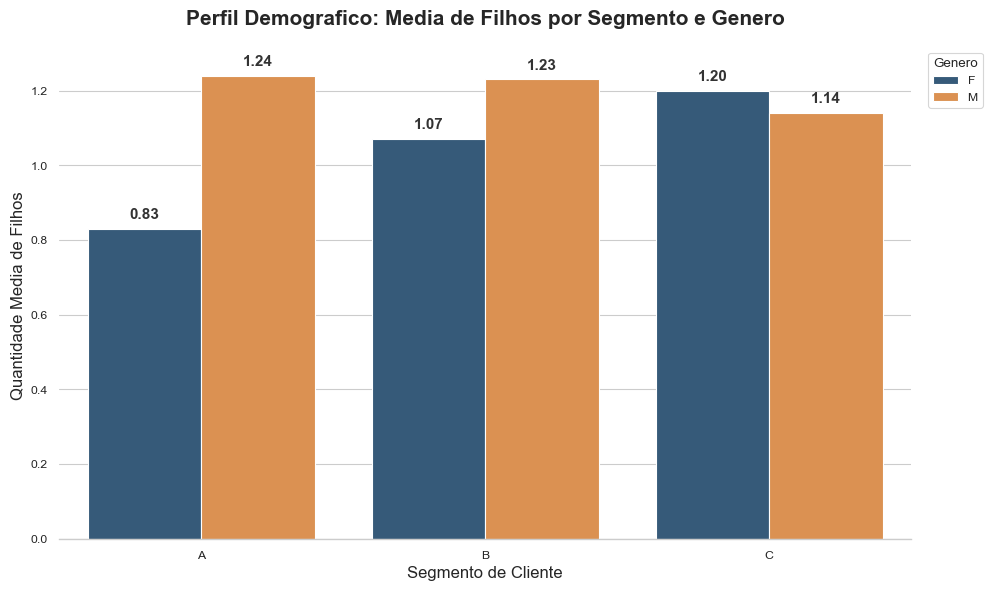

In [134]:
sns.set_theme(style="whitegrid", context="paper")
plt.figure(figsize=(10, 6))


ax = sns.barplot(
    data=perfil_segmento,
    x='CL_SEG',
    y='CL_FHL',
    hue='CL_GENERO',
    palette=['#2B5B84', '#F28F3B'] 
)

sns.despine(left=True, bottom=False)
for p in ax.containers:
    ax.bar_label(p, fmt='%.2f', padding=5, color='#333333', fontsize=11, fontweight='bold')


plt.title('Perfil Demografico: Media de Filhos por Segmento e Genero', fontsize=15, fontweight='bold', pad=20)
plt.xlabel('Segmento de Cliente', fontsize=12)
plt.ylabel('Quantidade Media de Filhos', fontsize=12)

plt.legend(title='Genero', bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)

plt.tight_layout()
plt.show()

### Conclusoes Finais

- 